# Project 2: Scene Reconstruction

## Timeline: 06/01/2026 10:00 AM - 06/22/2026 10:00 AM
## DUE-BY: 22.06.2026, 10:00 AM

This project addresses scene reconstruction.
You will use data from the public dataset [2014 Stereo Dataset](https://vision.middlebury.edu/stereo/data/scenes2014/), which contains stereo images of different objects.
You will estimate disparity and depth maps from the images, apply graphical models to smooth the results, and perform surface extraction of the 3D scene.

**Group Rules:**
Solo submissions will not be graded, please form groups of ideally three members with at least two. Each group member will need to mark their contributions to the code and this person will be responsible to answer questions. Make sure to register on time for the group presentations, registration will be possible until the submission deadline.

Submit your group's results through ILIAS and make sure all group members are registered. Please only upload your code and notebooks, **do not** upload the image data with your submission.


In [1]:
import cv2
from PIL import Image
from tqdm.auto import tqdm
try:
    import gco
except:
    pass
import numpy as np
import matplotlib.pyplot as plt
from functions_student import *
%matplotlib inline


d:\projects\uni\computer-vision\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Exercise 1

**Learning goals:** F-matrix estimation & Rectification

The goal of this exercise is to implement the F-matrix estimation to rectify two stereo images.

1. Load the provided stereo images (`data/img0.jpg` and `data/img1.jpg`). *Note: You are welcome to use your own camera photos to test your implementation, but your final code must work on the provided data.*
2. Use what you learned about feature descriptors and key point matching to find correspondences between the two images. Plot the detected points and matches. 
3. Use identified matches to estimate the fundamental matrix (F-matrix). You may use existing implementations for key point detection and matching, but you should implement the matrix estimation yourself.
4. Apply the estimated F-matrix to rectify the images.


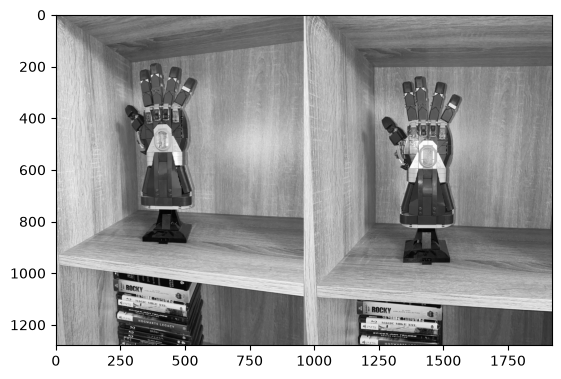

In [2]:
# Load images for Exercise 1
img1_ex1 = np.array(Image.open('data/img0.jpg').convert('L'))
img2_ex1 = np.array(Image.open('data/img1.jpg').convert('L'))
plt.imshow(np.hstack((img1_ex1, img2_ex1)), cmap='gray')
plt.show()


312 raw matches -> 191 RANSAC inliers


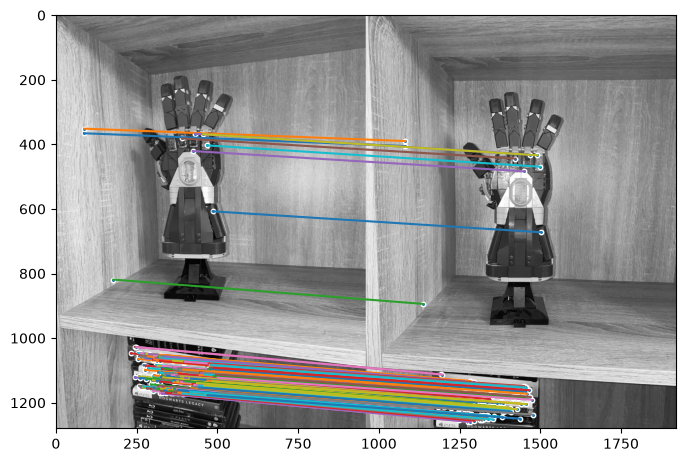

In [3]:
# Contributor: Malik
# 1. keypoints + descriptors (SIFT)
keypoints1, descriptors1 = get_keypoints(img1_ex1)
keypoints2, descriptors2 = get_keypoints(img2_ex1)

# 2. match descriptors (ratio test + cross checking)
matches = matching(descriptors1, descriptors2, max_ratio=0.7, cross_checking=True)
pts1 = keypoints1[matches[:, 0]]
pts2 = keypoints2[matches[:, 1]]

# 3. RANSAC via homography to drop outlier matches before estimating F
_, inlier_mask = cv2.findHomography(pts1, pts2, cv2.RANSAC, 5.0)
inlier_mask = inlier_mask.ravel().astype(bool)
keypoints1_match = pts1[inlier_mask]
keypoints2_match = pts2[inlier_mask]

print(f"{len(matches)} raw matches -> {len(keypoints1_match)} RANSAC inliers")

# 4. plot the matches
show_matching_result(img1_ex1, img2_ex1, keypoints1_match, keypoints2_match)
plt.show()


In [4]:
# Contributor: Malik
# normalized 8-point algorithm
F = compute_fundamental_matrix_normalized(keypoints1_match, keypoints2_match)
print('Fundamental Matrix:\n', F)


Fundamental Matrix:
 [[-3.87054795e-06  4.39698798e-06 -1.98886383e-02]
 [ 1.64553987e-05 -1.38400102e-06  9.32560782e-02]
 [ 9.27309661e-03 -1.03340068e-01  1.00000000e+00]]


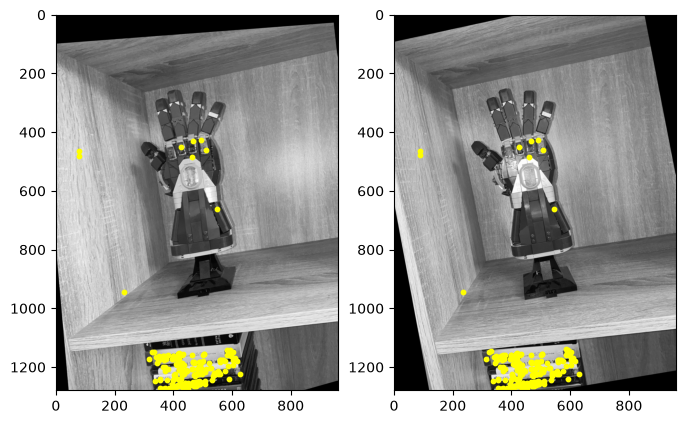

In [5]:
# Contributor: Malik
# rectification homographies from F + matches, then warp both images
h, w = img1_ex1.shape
_, H1, H2 = cv2.stereoRectifyUncalibrated(
    keypoints1_match.reshape(-1, 1, 2).astype(np.float32),
    keypoints2_match.reshape(-1, 1, 2).astype(np.float32),
    F,
    imgSize=(w, h),
)

img1_rectified_ex1 = cv2.warpPerspective(img1_ex1, H1, (w, h))
img2_rectified_ex1 = cv2.warpPerspective(img2_ex1, H2, (w, h))

# --- Visualization ---
def transform_points(points, matrix):
    points = np.hstack((points, np.ones((len(points), 1), dtype=np.float32)))
    points = (matrix @ points.T).T
    points = points[:, :2] / points[:, 2, np.newaxis]
    return points

if keypoints1_match is not None and H1 is not None:
    keypoints1_rectified_ex1 = transform_points(keypoints1_match, H1)
    keypoints2_rectified_ex1 = transform_points(keypoints2_match, H2)
    fig, axes = plt.subplots(1,2, figsize=(8,8))
    axes[0].imshow(img1_rectified_ex1, cmap='gray')
    axes[0].scatter(keypoints1_rectified_ex1[:,0], keypoints1_rectified_ex1[:,1], s=10, c='yellow')
    axes[1].imshow(img2_rectified_ex1, cmap='gray')
    axes[1].scatter(keypoints2_rectified_ex1[:,0], keypoints2_rectified_ex1[:,1], s=10, c='yellow')
    plt.show()


## Exercise 2

**Learning goals:** Compute scene depth using block matching

After rectifying images in the last exercise, the goal of this exercise will be to compute the scene depth. We will use a different pair of images for this task, located in `Sword1-perfect/`.

1. Compute the disparity using the methods described in the lecture.
   *Hint: We recommend using Sum of Absolute Differences (SAD) with a window size of 7x7 and the dynamically estimated maximum disparity.*
2. Implement Left-Right cross-checking to resolve ambiguous matches.
3. Use the computed disparity to estimate and display the depth.

**Tip:** If your implementation is too slow, you may downscale images to speed up computation.
**Note:** Please implement these algorithms yourself in `functions.py` or use the provided skeleton.


In [6]:
# Load images for Exercise 2 (Sword1-perfect)
img1_orig = np.array(Image.open('Sword1-perfect/im0.png').convert('RGB'))
img2_orig = np.array(Image.open('Sword1-perfect/im1.png').convert('RGB'))


In [7]:
# Contributor: Schams
# Estimate maximum disparity using keypoints
# 1. Extract keypoints and match them between the two original images
kp1_orig, desc1_orig = get_keypoints(img1_orig)
kp2_orig, desc2_orig = get_keypoints(img2_orig)
matches_orig = matching(desc1_orig, desc2_orig, max_ratio=0.7, cross_checking=True)
pts1_orig = kp1_orig[matches_orig[:, 0]]
pts2_orig = kp2_orig[matches_orig[:, 1]]

# 2. Compute the max expected disparity (99th percentile of horizontal shifts)
max_disparity_full = get_max_expected_disparity(pts1_orig, pts2_orig)

# 3. Scale down by 0.25 because we downscale the images by 0.25 below
max_disparity = int(np.ceil(max_disparity_full * 0.25))
print(f"max disparity (full res): {max_disparity_full} -> (downscaled): {max_disparity}")


max disparity (full res): 203 -> (downscaled): 51


In [8]:
# Prepare images for block matching
img1 = cv2.cvtColor(img1_orig, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0
img2 = cv2.cvtColor(img2_orig, cv2.COLOR_RGB2GRAY).astype(np.float32) / 255.0

# Downscale to speed up computation
img1 = cv2.resize(img1, (0,0), fx=0.25, fy=0.25, interpolation=cv2.INTER_LINEAR)
img2 = cv2.resize(img2, (0,0), fx=0.25, fy=0.25, interpolation=cv2.INTER_LINEAR)


In [9]:
# Contributor: Schams
window_size = 7
# Compute disparity maps for both directions (needed for cross-checking).
# L->R: left image fixed, search the right image; R->L: the opposite.
disparity_L = compute_disparity_map(img1, img2, window_size, max_disparity, direction="L->R")
disparity_R = compute_disparity_map(img2, img1, window_size, max_disparity, direction="R->L")


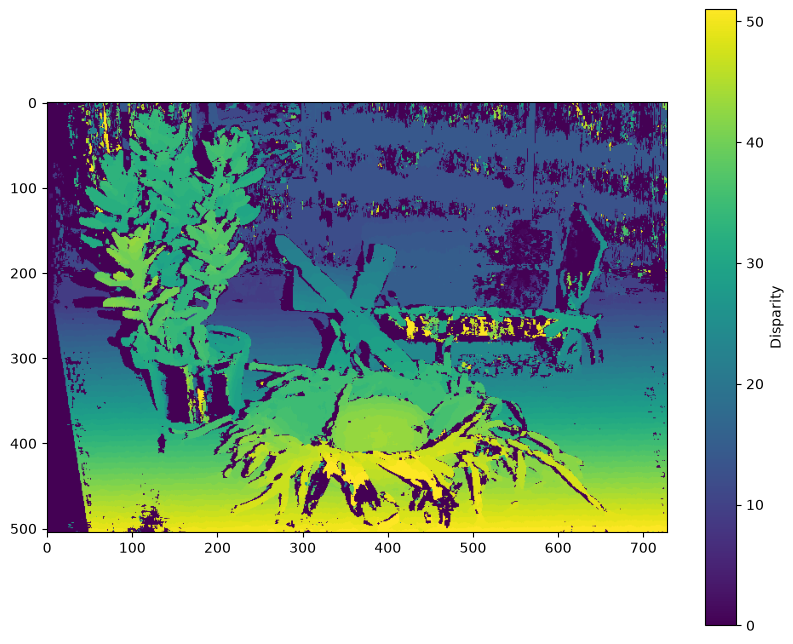

In [10]:
# Contributor: Schams
# Perform cross-checking to resolve ambiguous / occluded matches
disparity_map = cross_check_disparities(disparity_L, disparity_R, threshold=1.0)

# --- Visualization ---
if disparity_map is not None:
    plt.figure(figsize=(10, 8))
    plt.imshow(disparity_map, cmap='viridis')
    plt.colorbar(label='Disparity')
    plt.show()


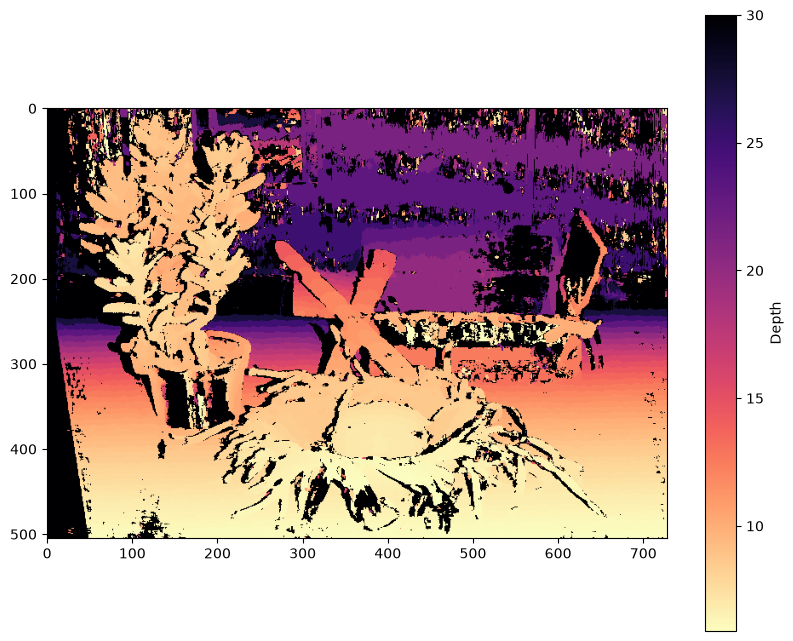

In [11]:
# Contributor: Schams
focal_length_pixels = 1718.2185
baseline_meters = 0.174724
# Estimate depth from disparity: Z = f * B / d
depth_map = estimate_depth(disparity_map, focal_length_pixels, baseline_meters)

# --- Visualization ---
if depth_map is not None:
    plt.figure(figsize=(10, 8))
    plt.imshow(np.nan_to_num(depth_map, nan=0, posinf=30), cmap='magma_r', vmax=30)
    plt.colorbar(label='Depth')
    plt.show()


## Exercise 3

**Learning goals:** Smooth depth maps using an MRF

To improve the quality of the depth estimation, you will now apply a Markov Random Field (MRF) to smooth the disparity maps.

1. Install `gco-wrapper`. If you are on Windows, ensure you have a C++ compiler installed. 
2. Convert the task of smoothing the disparity map into a MRF problem. 
   *Hint: For the MRF, consider defining your unary potentials as the absolute difference between the proposed label and the initial computed disparity. For pairwise potentials, a simple Potts model (penalizing adjacent pixels that have different disparity labels) works well.*
3. Recompute the depth map using your corrected disparity maps and compare them to the previous result.


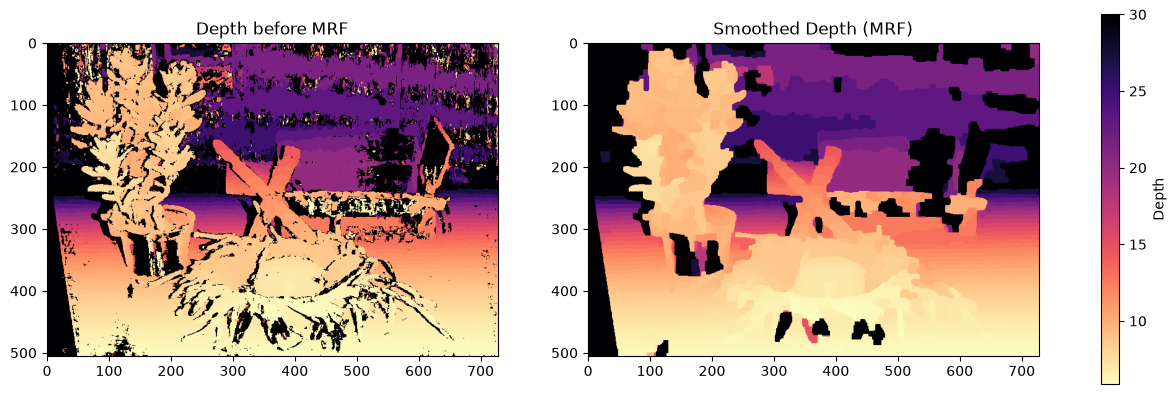

In [12]:
# Contributor: Samer
# smooth the disparity with the MRF, then recompute depth from it
smoothed_disparity = apply_mrf(disparity_map, max_disparity, lambda_=3)
smoothed_depth_map = estimate_depth(smoothed_disparity, focal_length_pixels, baseline_meters)
smoothed_depth_map = np.nan_to_num(smoothed_depth_map, nan=0, posinf=30)

# --- Visualization ---
if smoothed_depth_map is not None:
    fig, axes = plt.subplots(1, 2, figsize=(16, 6))
    axes[0].imshow(np.nan_to_num(depth_map, nan=0, posinf=30), cmap='magma_r', vmax=30)
    axes[0].set_title('Depth before MRF')
    im = axes[1].imshow(smoothed_depth_map, cmap='magma_r', vmax=30)
    axes[1].set_title('Smoothed Depth (MRF)')
    fig.colorbar(im, ax=axes, label='Depth', shrink=0.8)
    plt.show()


## Exercise 4 (Optional)

**Learning goals:** Scene surface construction (Marching Squares)

In this final exercise, you will apply surface extraction to create scene surfaces from the estimated depth map.

1. Implement the marching squares algorithm to extract isosurfaces from the depth maps.
   *Hint: Remember to handle the ambiguous saddle cases (where opposite corners share the same sign) by subsampling the center of the cell (averaging the 4 corners) as discussed in the lecture.*
2. Apply your algorithm to your previously created depth maps.
3. Plot the computed surfaces on top of the original images.

# Note: this exercise is ahead of the lecture and therefore optional.  


In [ ]:
isovalues = [5, 15, 25] # you may adjust these values to experiment
colors = ['red', 'green', 'blue']

# Individual plots
fig, axes = plt.subplots(1, 3, figsize=(18, 6))
for i, iso in enumerate(isovalues):
    segments = extract_surface_marching_squares(smoothed_depth_map, isovalue=iso)
    axes[i].imshow(img1, cmap='gray')
    axes[i].set_title(f'Isovalue {iso}')
    for pt1, pt2 in segments:
        axes[i].plot([pt1[0], pt2[0]], [pt1[1], pt2[1]], color=colors[i])
plt.show()

# Combined plot
plt.figure(figsize=(10, 8))
plt.imshow(img1, cmap='gray')
plt.title('Combined Surface Extractions')
for i, iso in enumerate(isovalues):
    segments = extract_surface_marching_squares(smoothed_depth_map, isovalue=iso)
    for pt1, pt2 in segments:
        plt.plot([pt1[0], pt2[0]], [pt1[1], pt2[1]], color=colors[i], label=f'Isovalue {iso}' if pt1 == segments[0][0] else '')
plt.legend()
plt.show()
